# Walkthrough - SVMs and Kernels

We will:
1. Train a linear SVM and *see* the margin and the support vectors.
2. Watch the soft-margin parameter $C$ trade margin width against violations.
3. Use kernels to separate non-linearly separable data.
4. Explore the $(C, \gamma)$ landscape of the RBF kernel.

Companion lesson: Lesson 01 - Support Vector Machines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def plot_svc_boundary(clf, X, y, ax, title=""):
    """Decision boundary, margins (dashed), and support vectors (circled)."""
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=20)
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300),
    )
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=1)
    ax.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], cmap="coolwarm", alpha=0.15)
    ax.scatter(*clf.support_vectors_.T, s=110, facecolors="none", edgecolors="k")
    ax.set_title(title, fontsize=9)

## Part 1 - The maximum-margin hyperplane

/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


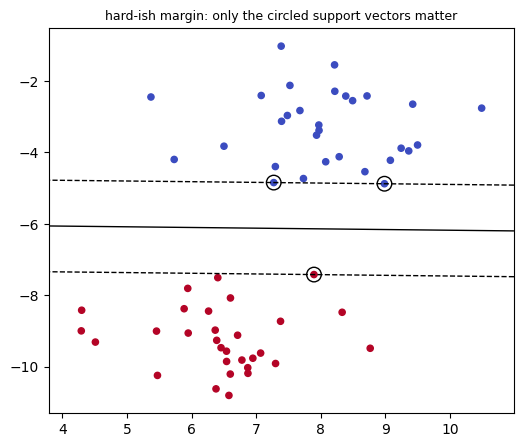

n_support vectors: 3 of 60 points


In [2]:
X, y = make_blobs(n_samples=60, centers=2, cluster_std=1.0, random_state=6)

clf = SVC(kernel="linear", C=1e6).fit(X, y)  # huge C ~ hard margin
fig, ax = plt.subplots(figsize=(6, 5))
plot_svc_boundary(clf, X, y, ax, "hard-ish margin: only the circled support vectors matter")
plt.show()
print(f"n_support vectors: {clf.n_support_.sum()} of {len(X)} points")

Delete any *non*-circled point and the solution would not move - the SVM summarizes
the dataset by its boundary cases ($w=\sum_i \alpha_i y_i x_i$, $\alpha_i > 0$ only on the margin).

## Part 2 - The soft margin: sweeping C

/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/private/tmp/claud

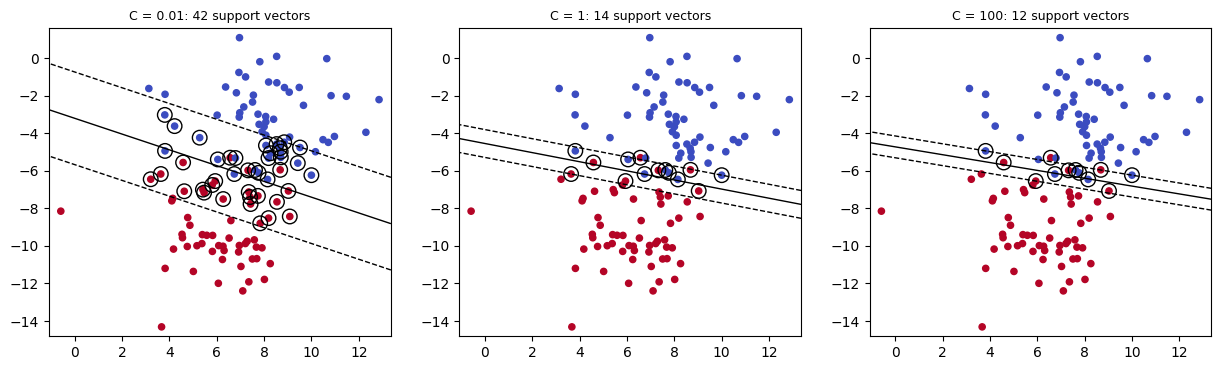

In [3]:
X, y = make_blobs(n_samples=120, centers=2, cluster_std=1.9, random_state=6)  # overlapping classes

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, C in zip(axes, [0.01, 1, 100]):
    clf = SVC(kernel="linear", C=C).fit(X, y)
    plot_svc_boundary(clf, X, y, ax, f"C = {C}: {clf.n_support_.sum()} support vectors")
plt.show()

Small $C$ -> wide, tolerant margin (many support vectors, more bias);
large $C$ -> narrow margin chasing every point (fewer support vectors, more variance).

## Part 3 - Kernels on non-separable data

/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


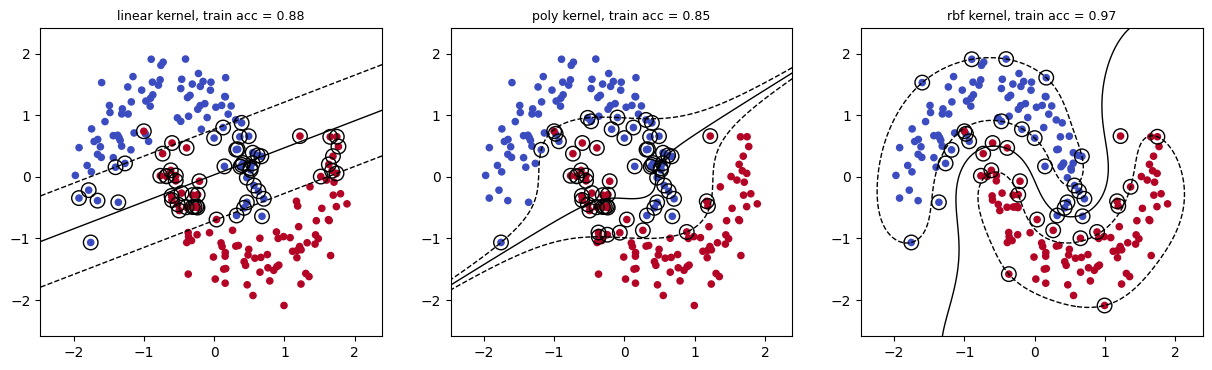

In [4]:
X, y = make_moons(n_samples=200, noise=0.15, random_state=0)
X = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (kernel, kw) in zip(
    axes,
    [("linear", {}), ("poly", {"degree": 3}), ("rbf", {"gamma": 1.0})],
):
    clf = SVC(kernel=kernel, C=1.0, **kw).fit(X, y)
    plot_svc_boundary(clf, X, y, ax, f"{kernel} kernel, train acc = {clf.score(X, y):.2f}")
plt.show()

Same algorithm, different inner product: the RBF kernel separates the moons because a
linear separator in its (infinite-dimensional) feature space is a nonlinear boundary here.

### The $\gamma$ knob is a length-scale

/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


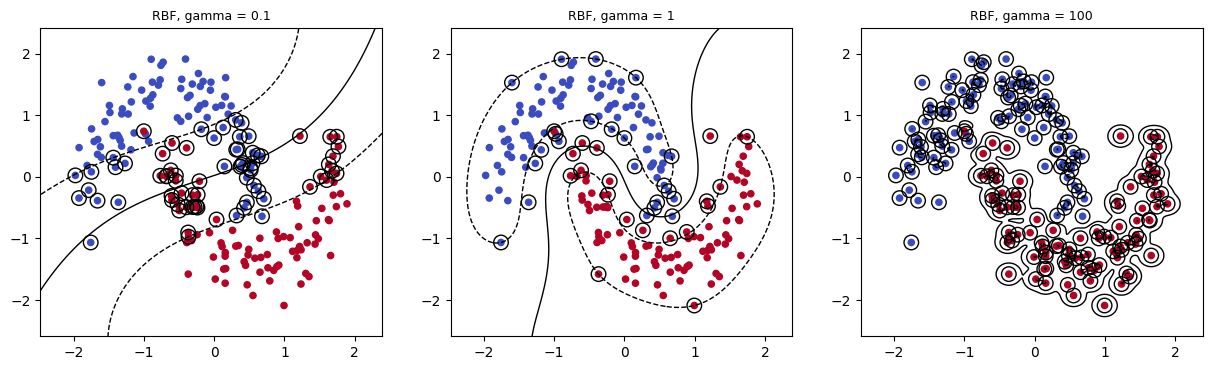

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, gamma in zip(axes, [0.1, 1, 100]):
    clf = SVC(kernel="rbf", C=1.0, gamma=gamma).fit(X, y)
    plot_svc_boundary(clf, X, y, ax, f"RBF, gamma = {gamma}")
plt.show()

`gamma=100` memorizes little islands around each training point - classic overfitting.

## Part 4 - Tuning $(C, \gamma)$ properly

best params: {'C': np.float64(100.0), 'gamma': np.float64(1.0)}, test accuracy: 1.000


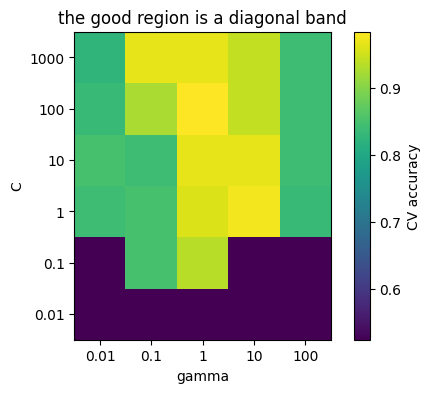

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0)

param_grid = {"C": np.logspace(-2, 3, 6), "gamma": np.logspace(-2, 2, 5)}
grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, n_jobs=-1).fit(X_train, y_train)
print(f"best params: {grid.best_params_}, test accuracy: {grid.score(X_test, y_test):.3f}")

scores = grid.cv_results_["mean_test_score"].reshape(len(param_grid["C"]), len(param_grid["gamma"]))
plt.figure(figsize=(6, 4))
plt.imshow(scores, origin="lower", cmap="viridis")
plt.colorbar(label="CV accuracy")
plt.xticks(range(len(param_grid["gamma"])), [f"{g:g}" for g in param_grid["gamma"]])
plt.yticks(range(len(param_grid["C"])), [f"{c:g}" for c in param_grid["C"]])
plt.xlabel("gamma"); plt.ylabel("C")
plt.title("the good region is a diagonal band")
plt.show()

### TODO exercises

1. Refit the Part 2 models *without* `StandardScaler` on features multiplied by `[1000, 1]`.
   What happens to the boundary, and why do kernels care about scaling when trees don't?
2. Compare `SVC(kernel="linear")` with `LogisticRegression` on the moons data - same template,
   different loss (hinge vs log). Where do the boundaries differ?
3. Compute the margin width $2/\|w\|$ for the three values of C in Part 2 (`clf.coef_`).
4. For the best RBF model, plot `decision_function` values on the test set as a histogram,
   split by class - these margins are what Platt scaling turns into probabilities.